# 01 Generate and Inspect Dataset

Generate a first real rectangular-dot dataset on a regular `(Lx, Ly)` grid and inspect it with a few basic plots.

Outputs:
- saved dataset: `data/rectangular_dataset_8_20.npz`
- heatmaps: `E0(Lx, Ly)`, `(E1 - E0)(Lx, Ly)`, `(E2 - E1)(Lx, Ly)`, `(E3 - E2)(Lx, Ly)`

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.dataset import generate_rectangular_dot_dataset

In [2]:
# Regular grid: Lx and Ly in 8..20 (inclusive).
lx_values = np.arange(8, 21, dtype=int)
ly_values = np.arange(8, 21, dtype=int)

out_path = PROJECT_ROOT / "data" / "rectangular_dataset_8_20.npz"
dataset = generate_rectangular_dot_dataset(lx_values, ly_values, save_path=out_path)

print(f"Saved: {out_path}")
print(f"Number of samples: {len(dataset['Lx'])}")
print(f"Unique Lx: {len(np.unique(dataset['Lx']))} ({dataset['Lx'].min()}..{dataset['Lx'].max()})")
print(f"Unique Ly: {len(np.unique(dataset['Ly']))} ({dataset['Ly'].min()}..{dataset['Ly'].max()})")
print(f"E0 range: {dataset['E0'].min():.6g} .. {dataset['E0'].max():.6g}")

Saved: D:\Diplom Physcis ML\Diplom Physcis ML\data\rectangular_dataset_8_20.npz
Number of samples: 169
Unique Lx: 13 (8..20)
Unique Ly: 13 (8..20)
E0 range: -3.95532 .. -3.75877


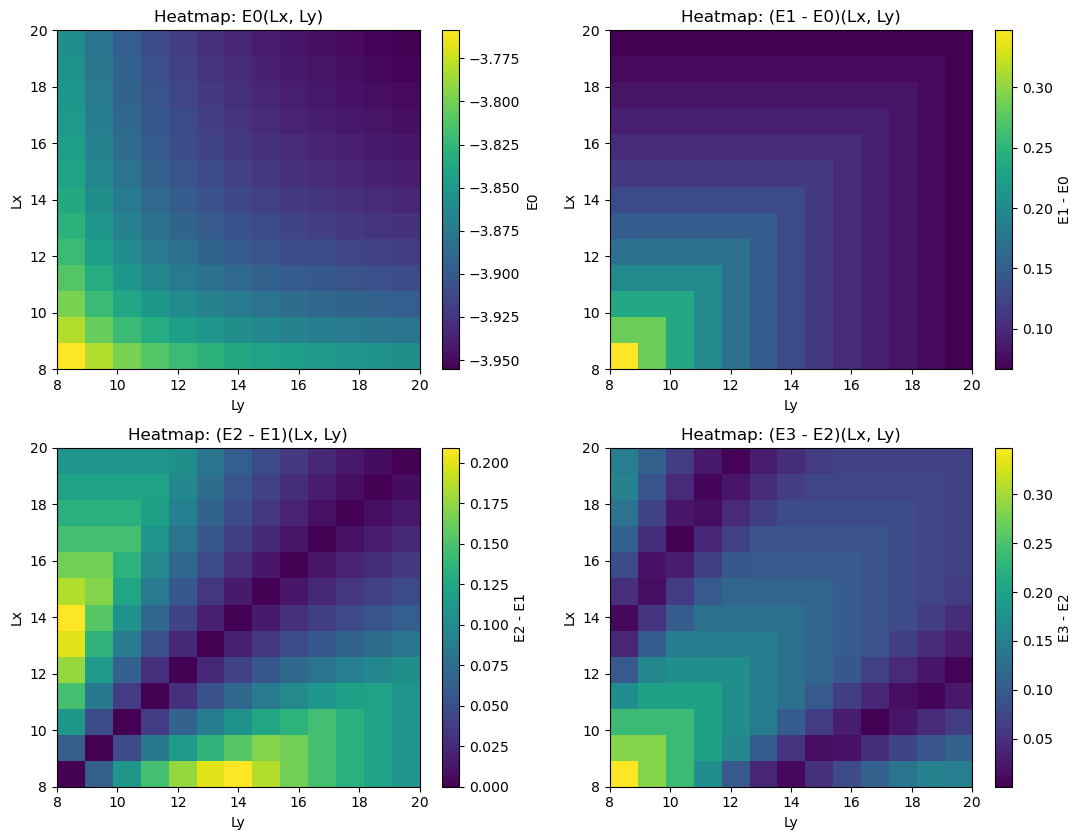

In [3]:
# Reshape flat arrays to 2D grids. The dataset is generated with Lx outer loop and Ly inner loop.
n_lx = len(lx_values)
n_ly = len(ly_values)

E0 = dataset["E0"].reshape(n_lx, n_ly)
gap10 = (dataset["E1"] - dataset["E0"]).reshape(n_lx, n_ly)
gap21 = (dataset["E2"] - dataset["E1"]).reshape(n_lx, n_ly)
gap32 = (dataset["E3"] - dataset["E2"]).reshape(n_lx, n_ly)

extent = [ly_values.min(), ly_values.max(), lx_values.min(), lx_values.max()]  # x=Ly, y=Lx

plt.figure(figsize=(11, 8.5))

plt.subplot(2, 2, 1)
im0 = plt.imshow(E0, origin="lower", extent=extent, aspect="auto")
plt.colorbar(im0, label="E0")
plt.xlabel("Ly")
plt.ylabel("Lx")
plt.title("Heatmap: E0(Lx, Ly)")

plt.subplot(2, 2, 2)
im1 = plt.imshow(gap10, origin="lower", extent=extent, aspect="auto")
plt.colorbar(im1, label="E1 - E0")
plt.xlabel("Ly")
plt.ylabel("Lx")
plt.title("Heatmap: (E1 - E0)(Lx, Ly)")

plt.subplot(2, 2, 3)
im2 = plt.imshow(gap21, origin="lower", extent=extent, aspect="auto")
plt.colorbar(im2, label="E2 - E1")
plt.xlabel("Ly")
plt.ylabel("Lx")
plt.title("Heatmap: (E2 - E1)(Lx, Ly)")

plt.subplot(2, 2, 4)
im3 = plt.imshow(gap32, origin="lower", extent=extent, aspect="auto")
plt.colorbar(im3, label="E3 - E2")
plt.xlabel("Ly")
plt.ylabel("Lx")
plt.title("Heatmap: (E3 - E2)(Lx, Ly)")

plt.tight_layout()
plt.show()